# HD 127195: target selection and first stability tests

Target selection from the NASA Exoplanet Archive, the adopted parameters (Figueira et al. 2026, with two corrections) and first tests: the best fit, 200 random configurations drawn within the uncertainties, and an eccentricity map. The final analysis for the paper, with finer grids, longer runs and the inclination scan, is `paper_analysis.py`.

## Target selection

In [1]:
# Multi-planet systems in the NASA Exoplanet Archive (Planetary Systems Composite table), keeping
# systems with a planet announced in 2025-2026 and known masses and eccentricities, sorted by
# their tightest period ratio.
import time
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rebound

def archive(query):
    # Query the archive's TAP service (ADQL) and return the result as a DataFrame.
    url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?" + urllib.parse.urlencode(
        {"query": query, "format": "csv"})
    return pd.read_csv(url)

multi = archive("select hostname, pl_name, disc_year, pl_orbper, pl_bmassj, pl_bmassprov, "
                "pl_orbeccen, st_mass from pscomppars where sy_pnum >= 2")

def tightest_ratio(periods):
    p = np.sort(periods.dropna().values)
    return (p[1:] / p[:-1]).min() if len(p) >= 2 else np.nan

summary = multi.groupby("hostname").agg(
    planets=("pl_name", "count"),
    newest_planet_year=("disc_year", "max"),
    all_masses_known=("pl_bmassj", lambda s: bool(s.notna().all())),
    all_ecc_known=("pl_orbeccen", lambda s: bool(s.notna().all())),
    mass_types=("pl_bmassprov", lambda s: ", ".join(sorted(set(s.dropna().astype(str))))),
    tightest_period_ratio=("pl_orbper", tightest_ratio),
)
candidates = summary[(summary.newest_planet_year >= 2025)
                     & summary.all_masses_known & summary.all_ecc_known].sort_values("tightest_period_ratio")
print(len(candidates), "candidate systems (tightest pairs first):")
candidates.head(40)

65 candidate systems (tightest pairs first):


,planets,newest_planet_year,all_masses_known,all_ecc_known,mass_types,tightest_period_ratio
hostname,,,,,,
Barnard's star,4,2025,True,True,Msini,1.307590
HIP 41378,6,2025,True,True,Mass,1.379338
Kepler-279,4,2025,True,True,Mass,1.522666
TOI-1453,2,2025,True,True,Mass,1.527452
TOI-5624,5,2026,True,True,"Mass, Msini",1.565014
HD 127195,2,2026,True,True,Msini,1.565931
L 98-59,5,2025,True,True,"Mass, Msini",1.638034
HD 20794,4,2025,True,True,"Msin(i)/sin(i), Msini",1.639384
DMPP-2,3,2026,True,True,Msini,1.642361


## Published parameter sets for HD 127195

In [2]:
# Every published parameter set for the host star in the Planetary Systems table.
HOST = "HD 127195"

rows = archive(
    "select pl_name, pl_refname, default_flag, pl_orbper, pl_orbpererr1, pl_orbpererr2, "
    "pl_bmassj, pl_bmassjerr1, pl_bmassjerr2, pl_bmassprov, "
    "pl_orbeccen, pl_orbeccenerr1, pl_orbeccenerr2, pl_orblper, "
    "st_mass, st_masserr1, st_masserr2 "
    f"from ps where hostname = '{HOST}' and upper(soltype) like '%CONF%'")
rows["reference"] = rows["pl_refname"].astype(str).str.replace(r"<[^>]+>", "", regex=True).str.strip()
rows[["pl_name", "reference", "default_flag", "pl_orbper", "pl_bmassj", "pl_bmassprov", "pl_orbeccen"]]

,pl_name,reference,default_flag,pl_orbper,pl_bmassj,pl_bmassprov,pl_orbeccen
0,HD 127195 b,Figueira et al. 2026,1,534.50,0.67,Msini,0.04
1,HD 127195 c,Figueira et al. 2026,1,836.99,0.65,Msini,0.05


## Adopted parameters and best fit

Parameters of Figueira et al. (2026), with the mean longitudes read from their Fig. C.2 and mass uncertainties from the semi-amplitude errors.

In [9]:
REFERENCE = "Figueira et al. 2026"

system = rows[rows["reference"] == REFERENCE].sort_values("pl_orbper").reset_index(drop=True)
if system.empty:
    raise ValueError(f"No rows match the reference {REFERENCE!r}.")

# Two corrections based on Figueira et al. (2026); rows are ordered b, c.
# 1. Orbital phase. Table 2 lists phi and omega, but the RVs constrain mainly their sum, the mean
#    longitude (the diagonal bands in their Fig. C.2). Summing the two medians would misplace
#    planet b by about 80 degrees, so lambda is read from Fig. C.2 and omega is drawn over its
#    full posterior width.
system["lam"] = [4.31, 1.00]          # mean longitude at the reference epoch [rad]
system["omega"] = [3.10, 4.12]        # Table 2 medians [rad; the table's degree label is a typo]
system["omega_err"] = [1.95, 1.82]    # Table 2 uncertainties, averaged [rad]
LAMBDA_ERR = 0.15                      # uncertainty of the mean longitude [rad] (estimate)
# 2. Mass uncertainties. The quoted +-0.02 MJ matches the stellar-mass error alone; the
#    semi-amplitude errors (13% and 15%) give about +-0.09 and +-0.10 MJ.
system["pl_bmassjerr1"] = [0.09, 0.10]
system["pl_bmassjerr2"] = [-0.09, -0.10]

print(system[["pl_name", "pl_orbper", "pl_bmassj", "pl_bmassprov", "pl_orbeccen", "st_mass"]])

MJUP = 9.547919e-4     # Jupiter's mass in solar masses
DAY = 1 / 365.25       # one day in years
ORDERLY_BELOW = 2.2    # MEGNO below this value = regular (orderly)
N_LONG = 10_000_000    # length of the long run, in orbits of the inner planet

def spread(err1, err2):
    # One symmetric uncertainty from the archive's upper (+) and lower (-) errors.
    vals = [abs(v) for v in (err1, err2) if pd.notna(v)]
    return float(np.mean(vals)) if vals else 0.0

def build(system, rng=None, mass_factor=1.0, eccs=None):
    # REBOUND simulation of the star and planets.
    # rng=None: best-fit values; rng given: one random draw within the uncertainties.
    # mass_factor: scales all planet masses (for example 1/sin i for inclined orbits).
    # eccs: list of eccentricities that overrides the table (used by the map).
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    first = system.iloc[0]
    m_star = first.st_mass
    if rng is not None:
        m_star = abs(rng.normal(m_star, spread(first.st_masserr1, first.st_masserr2)))
    sim.add(m=m_star)
    for k, r in system.iterrows():
        P = r.pl_orbper
        m = r.pl_bmassj
        e = r.pl_orbeccen if pd.notna(r.pl_orbeccen) else 0.0
        w = r.omega
        lam = r.lam
        if rng is not None:
            P = rng.normal(P, spread(r.pl_orbpererr1, r.pl_orbpererr2))
            m = abs(rng.normal(m, spread(r.pl_bmassjerr1, r.pl_bmassjerr2)))
            e = float(np.clip(rng.normal(e, spread(r.pl_orbeccenerr1, r.pl_orbeccenerr2)), 0, 0.9))
            w = rng.normal(w, r.omega_err)
            lam = rng.normal(lam, LAMBDA_ERR)
        if eccs is not None:
            e = eccs[k]
        sim.add(m=m * MJUP * mass_factor, P=P * DAY, e=e, omega=w, l=lam)
    sim.move_to_com()
    sim.integrator = "whfast"
    sim.dt = sim.particles[1].P / 30                  # 1/30 of the innermost orbit
    hill = [p.a * (p.m / (3 * m_star)) ** (1 / 3) for p in sim.particles[1:]]
    sim.exit_min_distance = min(hill)                 # close encounter: within the smaller Hill radius
    sim.exit_max_distance = 100 * max(p.a for p in sim.particles[1:])   # ejection
    return sim

def chaos(sim, inner_orbits=20_000):
    # MEGNO over this many orbits of the innermost planet; 8 = close encounter or ejection.
    sim.init_megno(seed=1)
    try:
        sim.integrate(inner_orbits * sim.particles[1].P, exact_finish_time=0)
        return min(sim.megno(), 8.0)
    except (rebound.Encounter, rebound.Escape):
        return 8.0

def survives(sim, inner_orbits=N_LONG):
    # Long run without MEGNO: True if no close encounter or ejection occurs.
    try:
        sim.integrate(inner_orbits * sim.particles[1].P, exact_finish_time=0)
        return True
    except (rebound.Encounter, rebound.Escape):
        return False

# Best fit: MEGNO, then a long run with an energy check.
sim = build(system)
score = chaos(sim)
print(f"Chaos score, best values:              {score:.2f}  ({'orderly' if score < ORDERLY_BELOW else 'CHAOTIC'})")
sim = build(system)
E0 = sim.energy()
ok = survives(sim)
if ok:
    print(f"Energy error after the long run:       {abs((sim.energy() - E0) / E0):.1e}")
print(f"Survives {N_LONG:,} inner orbits:      {ok}")
print(f"That is {N_LONG * sim.particles[1].P:,.0f} years for this system")
print(f"Chaos score with masses x2 (tilt test): {chaos(build(system, mass_factor=2.0)):.2f}")

       pl_name  pl_orbper  pl_bmassj pl_bmassprov  pl_orbeccen  st_mass
0  HD 127195 b     534.50       0.67        Msini         0.04     1.34
1  HD 127195 c     836.99       0.65        Msini         0.05     1.34
Chaos score, best values:              2.00  (orderly)
Energy error after the long run:       8.6e-08
Survives 10,000,000 inner orbits:      True
That is 14,633,077 years for this system
Chaos score with masses x2 (tilt test): 1.98


## 200 random configurations within the uncertainties

In [8]:
rng = np.random.default_rng(42)       # fixed seed: the same 200 draws on every run
N_DRAWS = 200
start = time.time()
scores = np.array([chaos(build(system, rng)) for _ in range(N_DRAWS)])
print(f"Finished in {time.time() - start:.0f} s")
print(f"Orderly (score < {ORDERLY_BELOW}): {np.mean(scores < ORDERLY_BELOW):.0%} of {N_DRAWS} draws")
print(f"Orderly (score < 2.5):  {np.mean(scores < 2.5):.0%}")
print(f"Score = 8 (chaotic or close encounter): {np.mean(scores >= 8.0):.0%}")

Finished in 49 s
Orderly (score < 2.2): 67% of 200 draws
Orderly (score < 2.5):  67%
Score = 8 (chaotic or close encounter): 31%


## Eccentricity map

column 40/40 done
Finished in 126 s


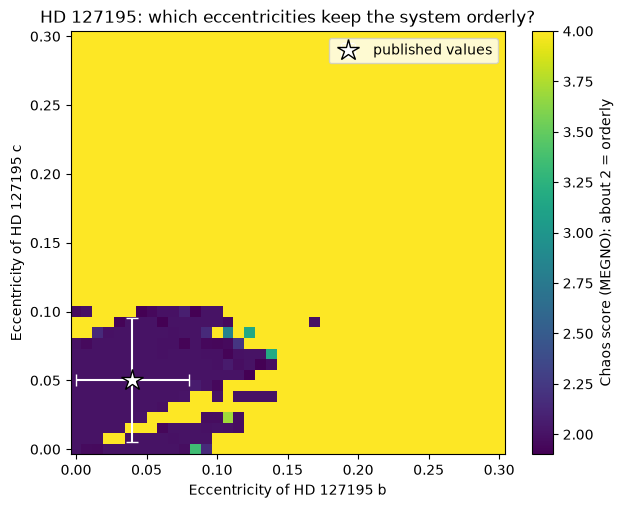

In [10]:
# Chaos map over the eccentricities of the closest pair (smallest period ratio), which
# interacts most strongly; other parameters at the best fit.
ratios = system.pl_orbper.values[1:] / system.pl_orbper.values[:-1]
i = int(np.argmin(ratios)); j = i + 1
E_MAX, N = 0.3, 40      # grid extent and resolution
e_grid = np.linspace(0, E_MAX, N)
best = [r.pl_orbeccen if pd.notna(r.pl_orbeccen) else 0.0 for _, r in system.iterrows()]

start = time.time()
chaos_grid = np.zeros((N, N))
for a, ei in enumerate(e_grid):
    for b, ej in enumerate(e_grid):
        eccs = list(best); eccs[i] = ei; eccs[j] = ej
        chaos_grid[b, a] = chaos(build(system, eccs=eccs), inner_orbits=20_000)
    print(f"\rcolumn {a + 1}/{N} done", end="")
print(f"\nFinished in {time.time() - start:.0f} s")

name_i, name_j = system.pl_name[i], system.pl_name[j]
fig, ax = plt.subplots(figsize=(7, 5.5))
mesh = ax.pcolormesh(e_grid, e_grid, chaos_grid, vmin=1.9, vmax=4.0, cmap="viridis", shading="nearest")
fig.colorbar(mesh, ax=ax, label="Chaos score (MEGNO): about 2 = orderly")
err_i = spread(system.pl_orbeccenerr1[i], system.pl_orbeccenerr2[i])
err_j = spread(system.pl_orbeccenerr1[j], system.pl_orbeccenerr2[j])
ax.errorbar(best[i], best[j], xerr=err_i, yerr=err_j, fmt="*", ms=16, color="white",
            mec="black", ecolor="white", capsize=4, label="published values")
ax.set_xlabel(f"Eccentricity of {name_i}")
ax.set_ylabel(f"Eccentricity of {name_j}")
ax.set_title(f"{HOST}: which eccentricities keep the system orderly?")
ax.legend(loc="upper right")
plt.savefig(f"{HOST}_stability_map.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

The best fit is regular (MEGNO = 2.00) and survives 10⁷ orbits of planet b (14.6 Myr) with a relative energy error of 8.6 × 10⁻⁸; doubling both masses leaves it regular (1.98). Of 200 configurations drawn within the uncertainties, about two-thirds are regular (67% in this run) and about a third reach the maximum score of 8. In the eccentricity map, regular orbits require e_c ≲ 0.1. The full analysis is in `paper_analysis.py`.